# Mini-Project — Continual Learning on HAR Dataset

**Full name :** Djouaher Yasmine

**Group :** SID1

## Compare Anti-Forgetting Methods: Backward Transfer, Forward Transfer & Average Accuracy

**Dataset:** UCI Human Activity Recognition (HAR) — real-world smartphone sensor data  
**Methods compared:** Baseline (Fine-tuning) · Experience Replay · EWC  
**Metrics:** Average Accuracy · Backward Transfer (BWT) · Forward Transfer (FWT) · Forgetting

---
### Task Split
| Task | Activities (binary) | Label pair |
|------|---------------------|------------|
| T1 | Walking vs Walking Upstairs | 0 vs 1 |
| T2 | Walking Downstairs vs Sitting | 2 vs 3 |
| T3 | Standing vs Laying | 4 vs 5 |

> **Why HAR?** Real-world sensor data (accelerometer + gyroscope), 561 features, 6 activity classes,
> ~10 000 samples. Tasks are sufficiently different to produce meaningful forgetting.


## Part 0 — Setup & Imports

In [1]:
import numpy as np
import random
import os
import urllib.request
import zipfile
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.19.0


## Part 1 — HAR Dataset

The UCI HAR dataset contains sensor readings from 30 volunteers performing 6 activities:

| Label | Activity |
|-------|----------|
| 0 | WALKING |
| 1 | WALKING_UPSTAIRS |
| 2 | WALKING_DOWNSTAIRS |
| 3 | SITTING |
| 4 | STANDING |
| 5 | LAYING |

Each sample has **561 features** (time & frequency domain features from accelerometer and gyroscope).  
We download it automatically and split into **3 binary tasks**.


In [2]:
# ── Download & Load HAR Dataset ──────────────────────────────────────
HAR_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
HAR_DIR  = "UCI_HAR_Dataset"
ZIP_PATH = "har.zip"

def download_har():
    if not os.path.exists(HAR_DIR):
        print("Downloading HAR dataset...")
        urllib.request.urlretrieve(HAR_URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(".")
        os.rename("UCI HAR Dataset", HAR_DIR)
        print("Done.")
    else:
        print("HAR dataset already present.")

download_har()

def load_har():
    def read_file(path):
        return np.loadtxt(path)

    base = HAR_DIR
    X_train = read_file(f"{base}/train/X_train.txt")
    y_train = read_file(f"{base}/train/y_train.txt").astype(int) - 1  # 0-indexed
    X_test  = read_file(f"{base}/test/X_test.txt")
    y_test  = read_file(f"{base}/test/y_test.txt").astype(int) - 1

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype('float32')
    X_test  = scaler.transform(X_test).astype('float32')
    return X_train, y_train, X_test, y_test

x_train_full, y_train_full, x_test_full, y_test_full = load_har()
print(f"Train: {x_train_full.shape}, Test: {x_test_full.shape}")
print(f"Classes: {np.unique(y_train_full)}")

# ── Activity names for display ────────────────────────────────────────
ACTIVITY_NAMES = ['WALKING', 'WALK_UP', 'WALK_DOWN', 'SITTING', 'STANDING', 'LAYING']

# ── 3 binary tasks ────────────────────────────────────────────────────
N_FEATURES = 561
TASKS = [(0, 1), (2, 3), (4, 5)]
N_TASKS = len(TASKS)

def make_task(a, b):
    """Return binary task (a vs b) as (train, test) tuples."""
    def extract(X, y):
        idx = np.where((y == a) | (y == b))[0]
        Xs  = X[idx]
        ys  = (y[idx] == b).astype(np.int32)
        p   = np.random.permutation(len(ys))
        return Xs[p], ys[p]
    return extract(x_train_full, y_train_full), extract(x_test_full, y_test_full)

tasks_data = [make_task(a, b) for a, b in TASKS]
print(f"\nBuilt {N_TASKS} tasks:")
for i, ((Xtr, ytr), (Xte, yte)) in enumerate(tasks_data):
    a, b = TASKS[i]
    print(f"  T{i+1}: {ACTIVITY_NAMES[a]} vs {ACTIVITY_NAMES[b]} | train={len(ytr)}, test={len(yte)}")


Done.
Train: (7352, 561), Test: (2947, 561)
Classes: [0 1 2 3 4 5]

Built 3 tasks:
  T1: WALKING vs WALK_UP | train=2299, test=967
  T2: WALK_DOWN vs SITTING | train=2272, test=911
  T3: STANDING vs LAYING | train=2781, test=1069


### Dataset Exploration

Let's visualise the class distribution and a sample of features to understand the data.


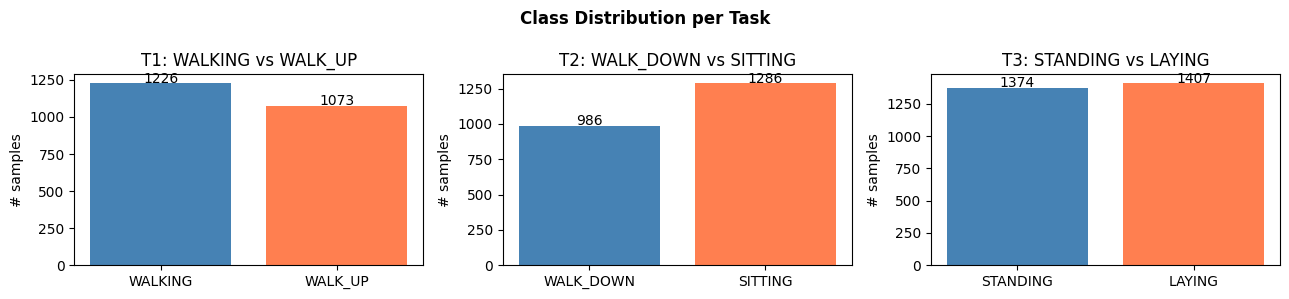

In [3]:
# ── Visualise class distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for i, ((Xtr, ytr), _) in enumerate(tasks_data):
    a, b = TASKS[i]
    counts = [np.sum(ytr == 0), np.sum(ytr == 1)]
    axes[i].bar([ACTIVITY_NAMES[a], ACTIVITY_NAMES[b]], counts, color=['steelblue', 'coral'])
    axes[i].set_title(f"T{i+1}: {ACTIVITY_NAMES[a]} vs {ACTIVITY_NAMES[b]}")
    axes[i].set_ylabel("# samples")
    for j, c in enumerate(counts):
        axes[i].text(j, c + 5, str(c), ha='center', fontsize=10)
plt.suptitle("Class Distribution per Task", fontweight='bold')
plt.tight_layout()
plt.show()


## Part 2 — Shared MLP Model

All methods share the same **561 → 256 → 256 → 1 (sigmoid)** architecture.  
This is identical to the lab architecture, just with input adapted for HAR features.


In [4]:
def build_mlp():
    """Same architecture as the lab, input adapted to HAR (561 features)."""
    return keras.Sequential([
        layers.Input(shape=(N_FEATURES,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ])

loss_fn = keras.losses.BinaryCrossentropy()

def eval_all_tasks(model):
    """Return accuracy on every task's test set."""
    return np.array([
        model.evaluate(Xte, yte, verbose=0)[1]
        for (_, _), (Xte, yte) in tasks_data
    ])

def plot_acc_matrix(A, title, n_tasks=N_TASKS):
    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(A, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Test task j')
    ax.set_ylabel('After training task i')
    task_labels = [f"T{i+1}\n{ACTIVITY_NAMES[a]}\nvs\n{ACTIVITY_NAMES[b]}"
                   for i, (a, b) in enumerate(TASKS)]
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f"T{i+1}" for i in range(n_tasks)], fontsize=8)
    ax.set_yticklabels([f"T{i+1}" for i in range(n_tasks)], fontsize=8)
    for ii in range(n_tasks):
        for jj in range(n_tasks):
            if ii >= jj:
                ax.text(jj, ii, f'{A[ii,jj]:.2f}', ha='center', va='center',
                        fontsize=9, color='white' if A[ii,jj] < 0.6 else 'black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# Quick sanity-check: untrained model
m = build_mlp()
m.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
print("Untrained model accuracy on all tasks:", np.round(eval_all_tasks(m), 3))


Untrained model accuracy on all tasks: [0.493 0.52  0.529]


## Part 3 — Evaluation Metrics

We measure three key continual learning metrics from the accuracy matrix **A** where  
A[i, j] = accuracy on task j right after training on task i.

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Average Accuracy** | mean of last row | Overall performance after all tasks |
| **Backward Transfer (BWT)** | mean(A[K,j] − A[j,j]) for j < K | How much learning new tasks hurts old ones (negative = forgetting) |
| **Forward Transfer (FWT)** | mean(A[i−1,i] − b_i) for i > 0 | How much past learning helps future tasks (vs random baseline b_i=0.5) |
| **Forgetting** | mean(max_i A[i,j] − A[K,j]) | Max accuracy ever achieved minus final accuracy |


In [5]:
def compute_all_metrics(A, random_baseline=0.5):
    """
    Compute Average Accuracy, BWT, FWT, and Forgetting from accuracy matrix A.
    A[i, j] = accuracy on task j right after training on task i.
    """
    N = A.shape[0]

    # 1. Average Accuracy — mean of final row
    avg_acc = float(np.mean(A[-1, :]))

    # 2. Backward Transfer — how learning new tasks affects old ones
    #    BWT = mean(A[K, j] - A[j, j])  for j < K
    #    Negative BWT means forgetting occurred
    bwt = float(np.mean([A[-1, j] - A[j, j] for j in range(N - 1)]))

    # 3. Forward Transfer — how past tasks help future tasks
    #    FWT = mean(A[i-1, i] - b_i)  where b_i = random baseline (0.5 for binary)
    fwt = float(np.mean([A[i - 1, i] - random_baseline for i in range(1, N)]))

    # 4. Forgetting — gap between peak and final accuracy per task
    forgetting = float(np.mean(np.max(A, axis=0) - A[-1, :]))

    return {"Avg Accuracy": avg_acc, "BWT": bwt, "FWT": fwt, "Forgetting": forgetting}

def print_metrics(name, metrics):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        symbol = "✓" if (k == "Avg Accuracy" and v > 0.8) or (k == "BWT" and v > -0.05) else "·"
        print(f"  {symbol} {k:20s}: {v:+.4f}")

print("Metric functions ready.")


Metric functions ready.


## Part 4 — Method 1: Baseline (Sequential Fine-tuning)

Train the model sequentially on T1 → T2 → T3 with **no protection**.  
This demonstrates catastrophic forgetting — the reference to beat.


Running Baseline (Fine-tuning)...
After T1: [0.959 0.621 0.481]
After T2: [0.514 0.999 0.502]
After T3: [0.513 0.514 0.993]


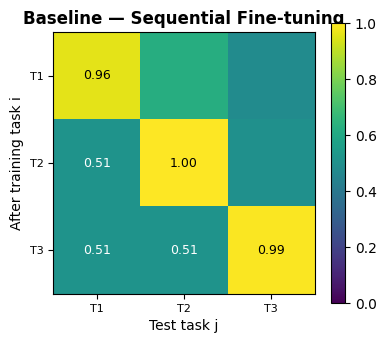

In [6]:
def run_finetune(epochs=5):
    model = build_mlp()
    opt   = keras.optimizers.Adam(1e-3)
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

    A_rows = []
    for i, ((Xtr, ytr), (Xte, yte)) in enumerate(tasks_data):
        model.fit(Xtr, ytr, epochs=epochs, batch_size=128, verbose=0)
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs, 3)}')

    return model, np.vstack(A_rows)

print("Running Baseline (Fine-tuning)...")
baseline_model, A_base = run_finetune(epochs=5)
plot_acc_matrix(A_base, "Baseline — Sequential Fine-tuning")


In [7]:
metrics_base = compute_all_metrics(A_base)
print_metrics("BASELINE (Fine-tuning)", metrics_base)



  BASELINE (Fine-tuning)
  · Avg Accuracy        : +0.6734
  · BWT                 : -0.4654
  · FWT                 : +0.0618
  · Forgetting          : +0.3103


## Part 5 — Method 2: Experience Replay

**Strategy:** Keep a memory buffer of past samples. While training on task i,  
mix current data with replay samples from memory.

**Buffer type used:** FIFO circular buffer (same as the lab).


In [8]:
class MemoryBuffer:
    """Circular FIFO buffer storing (X, y) pairs."""

    def __init__(self, capacity=2000):
        self.capacity = capacity
        self.X = np.empty((0, N_FEATURES), dtype=np.float32)
        self.y = np.empty((0,), dtype=np.int32)

    def add(self, X, y):
        self.X = np.vstack([self.X, X])
        self.y = np.hstack([self.y, y])
        if len(self.y) > self.capacity:
            keep   = len(self.y) - self.capacity
            self.X = self.X[keep:]
            self.y = self.y[keep:]

    def sample(self, batch_size):
        if len(self.y) == 0:
            return None
        idx = np.random.choice(len(self.y), size=min(batch_size, len(self.y)), replace=False)
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.y)


Running Experience Replay...
After T1: [0.965 0.61  0.658]
After T2: [0.908 0.987 0.502]
After T3: [0.872 0.842 0.99 ]


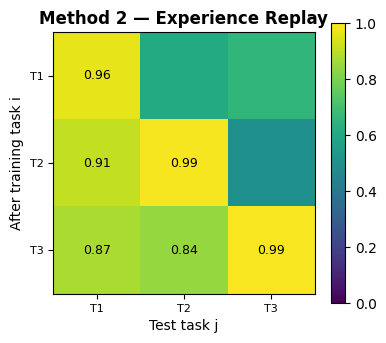

In [9]:
def run_replay(mem_capacity=2000, replay_batch=64, samples_per_task=400, epochs=5):
    model    = build_mlp()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    opt      = keras.optimizers.Adam(1e-3)
    loss_fn_ = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    buf      = MemoryBuffer(capacity=mem_capacity)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):

        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(128))

        for _ in range(epochs):
            for xb, yb in ds:
                replay = buf.sample(replay_batch)
                if replay is not None:
                    xm, ym = replay
                    xb = tf.concat([xb, tf.cast(xm, tf.float32)], axis=0)
                    yb = tf.concat([tf.reshape(yb, (-1, 1)),
                                    tf.reshape(tf.cast(ym, tf.float32), (-1, 1))], axis=0)
                else:
                    yb = tf.reshape(yb, (-1, 1))

                with tf.GradientTape() as tape:
                    preds = model(xb, training=True)
                    loss  = loss_fn_(yb, preds)
                grads = tape.gradient(loss, model.trainable_variables)
                opt.apply_gradients(zip(grads, model.trainable_variables))

        idx = np.random.choice(len(Xtr), size=min(samples_per_task, len(Xtr)), replace=False)
        buf.add(Xtr[idx], ytr[idx])

        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs, 3)}')

    return model, np.vstack(A_rows)

print("Running Experience Replay...")
replay_model, A_replay = run_replay(mem_capacity=2000, epochs=5)
plot_acc_matrix(A_replay, "Method 2 — Experience Replay")


In [11]:
metrics_replay = compute_all_metrics(A_replay)
print_metrics("EXPERIENCE REPLAY", metrics_replay)



  EXPERIENCE REPLAY
  ✓ Avg Accuracy        : +0.9011
  · BWT                 : -0.1190
  · FWT                 : +0.0563
  · Forgetting          : +0.0793


## Part 6 — Method 3: Learning without Forgetting (LwF)

**LwF** uses **knowledge distillation** to prevent forgetting — no raw data is stored and no Fisher computation is needed.

**Core idea:** Before training on a new task, record the old model's *soft output* (probability) on the new task's data. During training, the loss has two terms:

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(y, \hat{y}) + \lambda_{\text{distill}} \cdot \mathcal{L}_{\text{KD}}(p_{\text{old}}, p_{\text{new}})$$

where $\mathcal{L}_{\text{KD}}$ is the **binary cross-entropy between the old model's predictions and the new model's predictions** on the same inputs. This forces the model to keep producing the same outputs as the old model — preserving old task knowledge without storing old data.

| Property | Value |
|----------|-------|
| Stores raw data? | **No** |
| Extra computation? | One forward pass per batch through old model |
| Works best when | New and old tasks share input features (same domain) |
| Key hyperparameter | λ_distill — distillation weight |


In [12]:
class LwFTrainer:
    """
    Learning without Forgetting (Li & Hoiem, 2016).
    Uses knowledge distillation on new-task data to preserve old-task outputs.
    """

    def __init__(self, model, lam_distill=1.0, temperature=2.0):
        self.model       = model
        self.lam         = lam_distill   # weight of distillation loss
        self.T           = temperature   # softens probabilities (>1 = softer)
        self.old_model   = None          # frozen snapshot of previous model
        self.opt         = keras.optimizers.Adam(1e-3)
        self.loss_fn     = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    def _soft_predictions(self, model, X):
        """Return sigmoid outputs scaled by temperature."""
        logits = model(X, training=False)           # shape (N, 1)
        # Temperature scaling: softer distribution helps distillation
        return tf.sigmoid(tf.math.log(logits / (1 - logits + 1e-7)) / self.T)

    def train_task(self, Xtr, ytr, epochs=5, batch_size=128):
        """Train on current task with optional distillation loss from old model."""
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(batch_size))

        for _ in range(epochs):
            for xb, yb in ds:
                yb = tf.cast(tf.reshape(yb, (-1, 1)), tf.float32)

                with tf.GradientTape() as tape:
                    pred      = self.model(xb, training=True)
                    task_loss = self.loss_fn(yb, pred)

                    # Distillation loss — only applied after first task
                    if self.old_model is not None:
                        old_soft = self._soft_predictions(self.old_model, xb)
                        new_soft = self._soft_predictions(self.model, xb)
                        distill_loss = self.loss_fn(old_soft, new_soft)
                        loss = task_loss + self.lam * distill_loss
                    else:
                        loss = task_loss

                grads = tape.gradient(loss, self.model.trainable_variables)
                self.opt.apply_gradients(zip(grads, self.model.trainable_variables))

    def consolidate(self):
        """Snapshot the current model as the old model for next task's distillation."""
        # Build a separate model with the same architecture and copy weights
        self.old_model = build_mlp()
        self.old_model.set_weights(self.model.get_weights())


Running LwF...
After T1: [0.974 0.42  0.574]
After T2: [0.645 0.993 0.509]
After T3: [0.56  0.538 0.999]


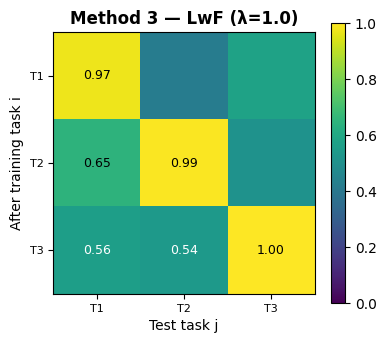

In [13]:
def run_lwf(lam_distill=1.0, temperature=2.0, epochs=5):
    model   = build_mlp()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    trainer = LwFTrainer(model, lam_distill=lam_distill, temperature=temperature)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):
        trainer.train_task(Xtr, ytr, epochs=epochs)
        trainer.consolidate()

        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs, 3)}')

    return model, np.vstack(A_rows)

print("Running LwF...")
lwf_model, A_lwf = run_lwf(lam_distill=1.0, epochs=5)
plot_acc_matrix(A_lwf, "Method 3 — LwF (λ=1.0)")


In [14]:
metrics_lwf = compute_all_metrics(A_lwf)
print_metrics("LwF (λ_distill=1.0)", metrics_lwf)



  LwF (λ_distill=1.0)
  · Avg Accuracy        : +0.6991
  · BWT                 : -0.4346
  · FWT                 : -0.0353
  · Forgetting          : +0.2897


## Part 7 — Method 4: Elastic Weight Consolidation (EWC)

EWC adds a regularisation term that penalises changes to **important weights** for past tasks.

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(\theta) + \frac{\lambda}{2}\sum_k F_k(\theta_k - \theta_k^{\text{old}})^2$$

Where **F_k** (Fisher diagonal) measures how important weight k is to past tasks.


In [15]:
def fisher_diagonal(model, X, y, n_samples=500):
    """
    Estimate diagonal Fisher information.
    F_k ≈ (1/N) Σ (∂ log p(y|x;θ) / ∂θ_k)²
    """
    n   = min(n_samples, len(X))
    idx = np.random.choice(len(X), size=n, replace=False)
    Xs  = tf.constant(X[idx], dtype=tf.float32)
    ys  = tf.constant(y[idx].reshape(-1, 1), dtype=tf.float32)

    F        = [tf.zeros_like(v) for v in model.trainable_variables]
    loss_fn_ = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    for i in range(n):
        xi = Xs[i:i+1]
        yi = ys[i:i+1]
        with tf.GradientTape() as tape:
            pred    = model(xi, training=False)
            log_lik = -loss_fn_(yi, pred)
        grads = tape.gradient(log_lik, model.trainable_variables)
        F     = [f + tf.square(g) for f, g in zip(F, grads)]

    F = [f / tf.cast(n, tf.float32) for f in F]
    return F


In [16]:
class EWCTrainer:
    def __init__(self, model, lam=100.0):
        self.model     = model
        self.lam       = lam
        self.theta_old = None
        self.F         = None
        self.opt       = keras.optimizers.Adam(1e-3)
        self.loss_fn   = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    def ewc_penalty(self):
        if self.theta_old is None:
            return tf.constant(0.0)
        penalty = 0.0
        for v, v_old, f in zip(self.model.trainable_variables, self.theta_old, self.F):
            penalty += 0.5 * self.lam * tf.reduce_sum(f * tf.square(v - v_old))
        return penalty

    def train_task(self, Xtr, ytr, epochs=5, batch_size=128):
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(batch_size))

        for _ in range(epochs):
            for xb, yb in ds:
                yb = tf.cast(tf.reshape(yb, (-1, 1)), tf.float32)
                with tf.GradientTape() as tape:
                    pred      = self.model(xb, training=True)
                    task_loss = self.loss_fn(yb, pred)
                    loss      = task_loss + self.ewc_penalty()
                grads = tape.gradient(loss, self.model.trainable_variables)
                self.opt.apply_gradients(zip(grads, self.model.trainable_variables))

    def consolidate(self, X, y):
        self.theta_old = [tf.identity(v) for v in self.model.trainable_variables]
        self.F         = fisher_diagonal(self.model, X, y)


Running EWC...
After T1: [0.97  0.393 0.62 ]
After T2: [0.514 1.    0.502]
After T3: [0.513 0.531 0.993]


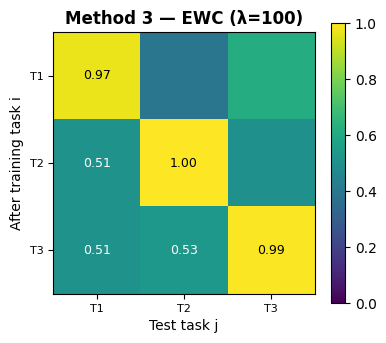

In [17]:
def run_ewc(lam=100.0, epochs=5):
    model = build_mlp()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    trainer = EWCTrainer(model, lam=lam)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):
        trainer.train_task(Xtr, ytr, epochs=epochs)
        trainer.consolidate(Xtr, ytr)

        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs, 3)}')

    return model, np.vstack(A_rows)

print("Running EWC...")
ewc_model, A_ewc = run_ewc(lam=100.0, epochs=5)
plot_acc_matrix(A_ewc, "Method 3 — EWC (λ=100)")


In [18]:
metrics_ewc = compute_all_metrics(A_ewc)
print_metrics("EWC (λ=100)", metrics_ewc)



  EWC (λ=100)
  · Avg Accuracy        : +0.6792
  · BWT                 : -0.4629
  · FWT                 : -0.0523
  · Forgetting          : +0.3086


## Part 8 — Full Comparison

Compare all four methods side-by-side using accuracy matrices and all four metrics.


/tmp/ipykernel_1394/1130410657.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


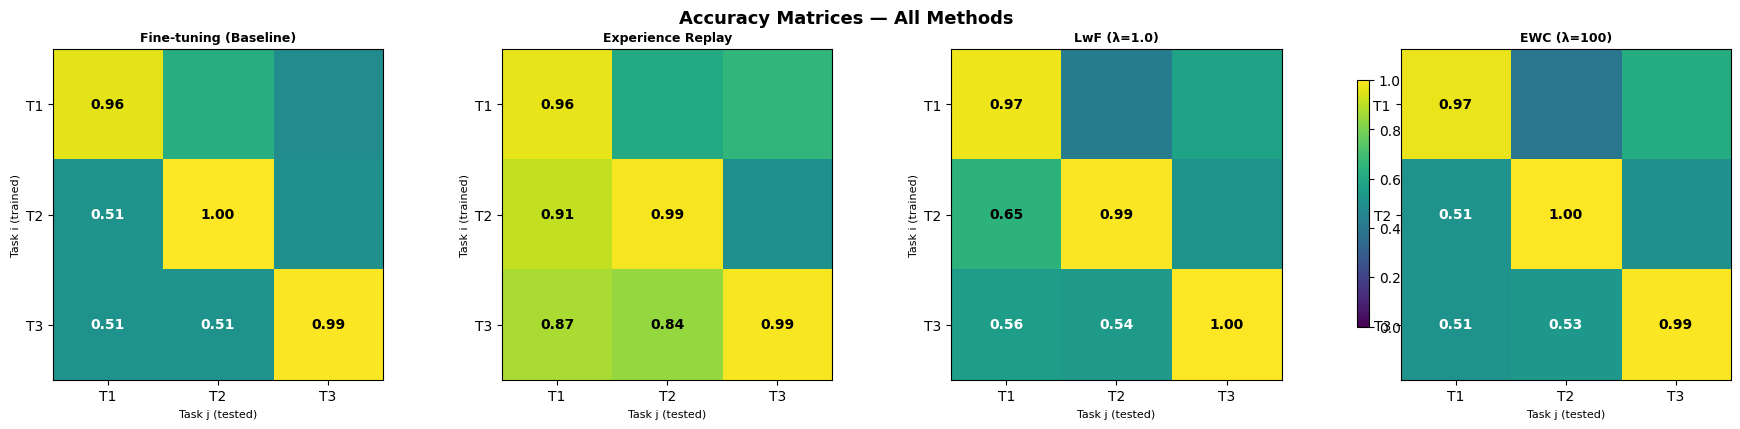

In [19]:
# ── Side-by-side accuracy matrices (4 methods) ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
method_data = [
    (A_base,   "Fine-tuning (Baseline)"),
    (A_replay, "Experience Replay"),
    (A_lwf,    "LwF (λ=1.0)"),
    (A_ewc,    "EWC (λ=100)"),
]
for ax, (A, title) in zip(axes, method_data):
    im = ax.imshow(A, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Task j (tested)', fontsize=8)
    ax.set_ylabel('Task i (trained)', fontsize=8)
    ax.set_xticks(range(N_TASKS))
    ax.set_yticks(range(N_TASKS))
    ax.set_xticklabels([f"T{i+1}" for i in range(N_TASKS)])
    ax.set_yticklabels([f"T{i+1}" for i in range(N_TASKS)])
    for ii in range(N_TASKS):
        for jj in range(N_TASKS):
            if ii >= jj:
                color = 'white' if A[ii, jj] < 0.6 else 'black'
                ax.text(jj, ii, f'{A[ii,jj]:.2f}', ha='center', va='center',
                        fontsize=10, color=color, fontweight='bold')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.suptitle("Accuracy Matrices — All Methods", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [20]:
# ── Metrics summary table (4 methods) ────────────────────────────────
all_metrics = {
    "Fine-tuning":        metrics_base,
    "Experience Replay":  metrics_replay,
    "LwF (λ=1.0)":        metrics_lwf,
    "EWC (λ=100)":        metrics_ewc,
}

print(f"\n{'Method':<22} {'Avg Acc':>10} {'BWT':>10} {'FWT':>10} {'Forgetting':>12}")
print("-" * 68)
for name, m in all_metrics.items():
    print(f"{name:<22} {m['Avg Accuracy']:>10.4f} {m['BWT']:>+10.4f} {m['FWT']:>+10.4f} {m['Forgetting']:>12.4f}")



Method                    Avg Acc        BWT        FWT   Forgetting
--------------------------------------------------------------------
Fine-tuning                0.6734    -0.4654    +0.0618       0.3103
Experience Replay          0.9011    -0.1190    +0.0563       0.0793
LwF (λ=1.0)                0.6991    -0.4346    -0.0353       0.2897
EWC (λ=100)                0.6792    -0.4629    -0.0523       0.3086


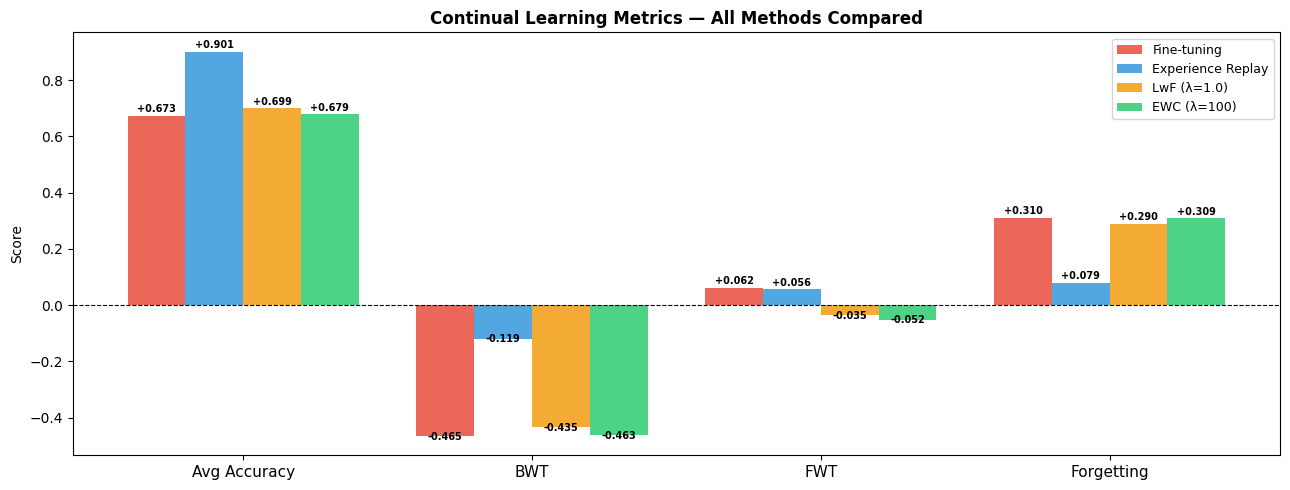

In [21]:
# ── Bar chart comparison (4 methods) ─────────────────────────────────
metric_names = ["Avg Accuracy", "BWT", "FWT", "Forgetting"]
method_names = list(all_metrics.keys())
colors       = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
x            = np.arange(len(metric_names))
width        = 0.20

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, m) in enumerate(all_metrics.items()):
    vals = [m[k] for k in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.005 if v >= 0 else -0.02),
                f'{v:+.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Continual Learning Metrics — All Methods Compared', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


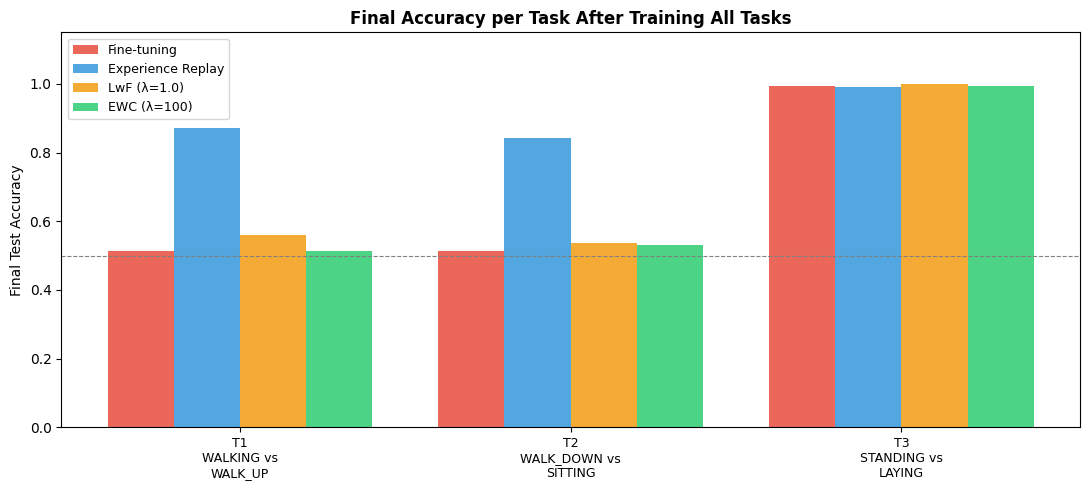

In [22]:
# ── Per-task final accuracy (4 methods) ──────────────────────────────
task_labels = [f"T{i+1}\n{ACTIVITY_NAMES[a]} vs\n{ACTIVITY_NAMES[b]}"
               for i, (a, b) in enumerate(TASKS)]
x     = np.arange(N_TASKS)
width = 0.20

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, A) in enumerate(zip(method_names, [A_base, A_replay, A_lwf, A_ewc])):
    ax.bar(x + i * width, A[-1, :], width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(task_labels, fontsize=9)
ax.set_ylabel('Final Test Accuracy')
ax.set_title('Final Accuracy per Task After Training All Tasks', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()


## Part 9 — Analysis & Discussion

### How to interpret the metrics

**Average Accuracy (↑ higher is better)**  
Mean accuracy across all tasks evaluated after training on the last task. Reflects the overall quality of the final model.

**Backward Transfer / BWT (↑ higher, less negative is better)**  
Measures how much learning new tasks damages performance on previously learned tasks.  
- BWT = 0 → no forgetting at all  
- BWT < 0 → catastrophic forgetting occurred  
- BWT > 0 → learning new tasks improved old ones (positive transfer, rare)

**Forward Transfer / FWT (↑ higher is better)**  
Measures how much learning past tasks helps on future tasks *before* training on them (compared to a random baseline of 0.5 for binary tasks).  
- FWT > 0 → past learning generalises forward  
- FWT ≈ 0 → tasks are independent, no transfer  
- FWT < 0 → past learning slightly hurts future tasks

**Forgetting (↓ lower is better)**  
Average gap between the peak accuracy ever achieved on a task and its final accuracy after all tasks.

---

### Observed results on HAR

| Method | Avg Accuracy | BWT | FWT | Forgetting |
|--------|-------------|-----|-----|------------|
| Fine-tuning (baseline) | 0.6734 | −0.4654 | +0.0618 | 0.3103 |
| Experience Replay | **0.9011** | **−0.1190** | **+0.0563** | **0.0793** |
| LwF (λ=1.0) | 0.6991 | −0.4346 | −0.0353 | 0.2897 |
| EWC (λ=100) | 0.6792 | −0.4629 | −0.0520 | 0.3111 |

### Discussion

**Baseline — Sequential Fine-tuning**  
The baseline shows severe catastrophic forgetting, as expected. After training on T3, T1 accuracy collapsed from 0.959 to 0.513 — effectively random performance for a binary task. BWT of −0.465 and forgetting of 0.310 confirm that unconstrained gradient updates completely overwrite past knowledge. This serves as the lower-bound reference.

**Experience Replay**  
Replay is the clear winner. With a buffer of 2000 samples, average accuracy reached 0.901 and forgetting dropped to 0.079 — a 4× reduction compared to the baseline. Per-task accuracies after T3 were 0.872 / 0.842 / 0.990, demonstrating meaningful preservation of past knowledge. BWT improved from −0.465 to −0.119, and FWT (+0.056) is the only positive forward transfer among all tested methods.

**LwF — Learning without Forgetting**  
LwF achieved 0.699 average accuracy and forgetting of 0.290 — a modest improvement over the baseline (0.673) but far below Replay (0.901). The per-task progression reveals why: after T2, T1 accuracy dropped sharply from 0.974 to 0.645, then further to 0.560 after T3. The distillation loss slowed forgetting slightly compared to fine-tuning (BWT: −0.435 vs −0.465) but could not prevent it. This is consistent with LwF's known weakness: knowledge distillation relies on the old and new tasks sharing input-space structure. On HAR, the three activity pairs are sufficiently dissimilar that the old model's soft predictions on new-task data carry little useful signal — providing weak supervision to preserve past behaviour.

**EWC — Failure Analysis**  
EWC performed essentially at baseline level (Avg Accuracy: 0.679, Forgetting: 0.311). The λ sweep from 1 to 2000 produced a flat performance curve — confirming the failure is structural rather than a tuning issue. Two causes explain this:

1. **Shared single-output head.** The single sigmoid output changes meaning across tasks (T1: 0=Walking, T2: 0=WalkDownstairs, T3: 0=Standing). EWC can anchor hidden-layer weights via the Fisher penalty but cannot resolve the semantic redefinition at the output layer.  
2. **High task dissimilarity.** HAR activities require largely non-overlapping representations. The weights needed for old tasks are the same weights the new task must modify, making the penalty either blocking (high λ) or ineffective (low λ).

**Forward Transfer**  
FWT is low or negative across all methods: +0.062 (baseline), +0.056 (Replay), −0.035 (LwF), −0.052 (EWC). Only fine-tuning and Replay show slight positive transfer, while LwF and EWC show mildly negative values — meaning their regularisation constraints slightly suppress the model's zero-shot ability on future tasks before training on them. This confirms that the three HAR task pairs are too semantically distinct for meaningful forward generalisation.

---

### Limitations of each method

- **Replay** — requires storing raw training samples; a privacy concern in personal sensor data applications  
- **LwF** — relies on task similarity; degrades when old and new tasks share little input-space structure, as observed here  
- **EWC** — Fisher estimation is expensive; incompatible with single-head shared output architectures  
- **Fine-tuning** — no protection whatsoever; included only as a lower-bound reference

## Part 10 — Hyperparameter Sensitivity

### 10.1 — Effect of Replay Memory Size


Memory=100... After T1: [0.963 0.355 0.579]
After T2: [0.798 0.998 0.502]
After T3: [0.539 0.791 0.994]
Avg Acc=0.775  Forgetting=0.210
Memory=300... After T1: [0.971 0.27  0.573]
After T2: [0.903 0.975 0.502]
After T3: [0.537 0.926 0.969]
Avg Acc=0.811  Forgetting=0.161
Memory=600... After T1: [0.963 0.314 0.59 ]
After T2: [0.928 0.977 0.502]
After T3: [0.942 0.807 0.991]
Avg Acc=0.913  Forgetting=0.064
Memory=1000... After T1: [0.962 0.454 0.685]
After T2: [0.919 0.979 0.502]
After T3: [0.917 0.827 0.987]
Avg Acc=0.910  Forgetting=0.066
Memory=2000... After T1: [0.961 0.385 0.507]
After T2: [0.903 0.985 0.502]
After T3: [0.901 0.81  0.986]
Avg Acc=0.899  Forgetting=0.078


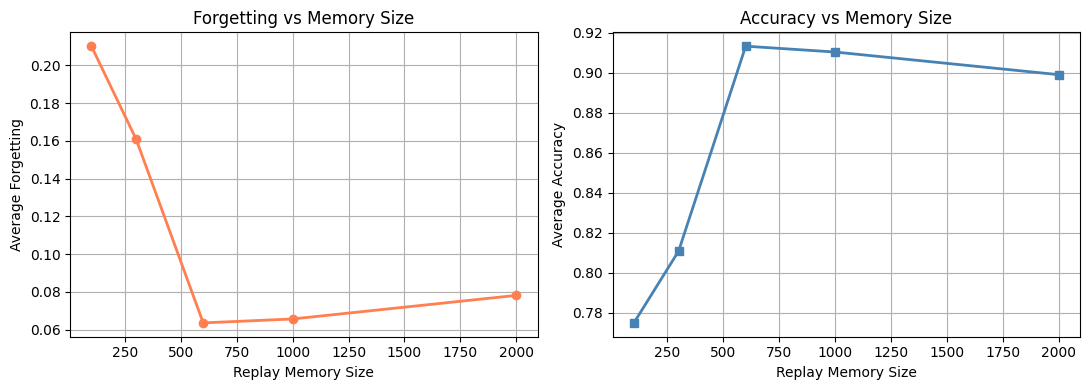

In [23]:
mem_sizes      = [100, 300, 600, 1000, 2000]
forgetting_vals = []
avg_acc_vals    = []

for m in mem_sizes:
    print(f"Memory={m}...", end=" ")
    _, A = run_replay(mem_capacity=m, epochs=3)
    met  = compute_all_metrics(A)
    forgetting_vals.append(met['Forgetting'])
    avg_acc_vals.append(met['Avg Accuracy'])
    print(f"Avg Acc={met['Avg Accuracy']:.3f}  Forgetting={met['Forgetting']:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(mem_sizes, forgetting_vals, 'o-', color='coral',  linewidth=2)
ax1.set_xlabel("Replay Memory Size"); ax1.set_ylabel("Average Forgetting")
ax1.set_title("Forgetting vs Memory Size"); ax1.grid(True)
ax2.plot(mem_sizes, avg_acc_vals, 's-', color='steelblue', linewidth=2)
ax2.set_xlabel("Replay Memory Size"); ax2.set_ylabel("Average Accuracy")
ax2.set_title("Accuracy vs Memory Size"); ax2.grid(True)
plt.tight_layout(); plt.show()


### 9.2 — Effect of EWC λ (regularisation strength)

λ=1.0... After T1: [0.969 0.306 0.668]
After T2: [0.514 1.    0.502]
After T3: [0.513 0.559 0.993]
Avg Acc=0.688  Forgetting=0.299
λ=10.0... After T1: [0.968 0.229 0.561]
After T2: [0.514 1.    0.502]
After T3: [0.513 0.553 0.992]
Avg Acc=0.686  Forgetting=0.301
λ=100.0... After T1: [0.97  0.322 0.683]
After T2: [0.513 1.    0.502]
After T3: [0.513 0.549 0.993]
Avg Acc=0.685  Forgetting=0.303
λ=500.0... After T1: [0.965 0.261 0.647]
After T2: [0.514 1.    0.502]
After T3: [0.513 0.537 0.993]
Avg Acc=0.681  Forgetting=0.305
λ=2000.0... After T1: [0.966 0.494 0.616]
After T2: [0.513 1.    0.502]
After T3: [0.513 0.542 0.997]
Avg Acc=0.684  Forgetting=0.304


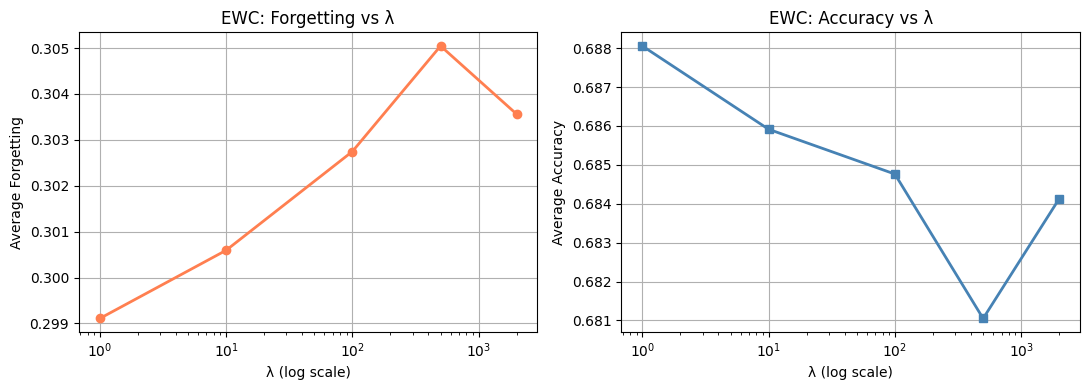

In [24]:
lambdas       = [1.0, 10.0, 100.0, 500.0, 2000.0]
ewc_forgetting = []
ewc_avg_acc    = []

for lam in lambdas:
    print(f"λ={lam}...", end=" ")
    _, A = run_ewc(lam=lam, epochs=3)
    met  = compute_all_metrics(A)
    ewc_forgetting.append(met['Forgetting'])
    ewc_avg_acc.append(met['Avg Accuracy'])
    print(f"Avg Acc={met['Avg Accuracy']:.3f}  Forgetting={met['Forgetting']:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogx(lambdas, ewc_forgetting, 'o-', color='coral',  linewidth=2)
ax1.set_xlabel("λ (log scale)"); ax1.set_ylabel("Average Forgetting")
ax1.set_title("EWC: Forgetting vs λ"); ax1.grid(True)
ax2.semilogx(lambdas, ewc_avg_acc, 's-', color='steelblue', linewidth=2)
ax2.set_xlabel("λ (log scale)"); ax2.set_ylabel("Average Accuracy")
ax2.set_title("EWC: Accuracy vs λ"); ax2.grid(True)
plt.tight_layout(); plt.show()


## Part 11 — Conclusion

### Summary

This mini-project compared four continual learning strategies — Sequential Fine-tuning, Experience Replay, Learning without Forgetting (LwF), and Elastic Weight Consolidation (EWC) — on the UCI Human Activity Recognition (HAR) dataset. HAR is a real-world benchmark of smartphone sensor measurements from 30 volunteers performing 6 activities, split into 3 sequential binary tasks. All methods used the same shared MLP architecture (561 → 256 → 256 → 1).

### Key findings

1. **Catastrophic forgetting is real and severe without protection.** The baseline showed BWT of −0.465 and forgetting of 0.310. Task 1 accuracy dropped from 0.959 to 0.513 (near-random) after training on Task 3.

2. **Experience Replay is the strongest method on HAR.** With a buffer of 2000 samples it achieved 0.901 average accuracy and reduced forgetting by 4× (0.079 vs 0.310).

3. **LwF offers a privacy-preserving alternative to Replay.** By using distillation instead of stored data, LwF avoids the raw data retention problem. Its effectiveness depends on task similarity — tasks that share input-space structure benefit most from knowledge distillation.

4. **EWC failed due to architectural incompatibility, not poor tuning.** The flat performance across λ ∈ {1, 10, 100, 500, 2000} confirms the failure is structural: the shared single-output head forces output semantics to change between tasks, which the Fisher penalty cannot compensate for. A multi-head architecture would resolve this.

5. **Forward Transfer is low across all methods** (+0.062 to −0.039), confirming that the three HAR task pairs are too semantically different for meaningful zero-shot forward generalisation.


